# 🏥 Medical Intent Classifier

## ── SECTION 0: Environment, Seeds & Logging ──

In [1]:
import sys, platform, importlib, datetime, os
os.environ["PYTHONIOENCODING"] = "utf-8"

print("=" * 55)
print("ENVIRONMENT INFO")
print("=" * 55)
print(f"Date/Time  : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python     : {sys.version.split()[0]}")
print(f"Platform   : {platform.platform()}")
for pkg in ["numpy", "pandas", "sklearn", "spacy", "datasets", "matplotlib", "seaborn", "joblib"]:
    try:
        m = importlib.import_module(pkg)
        print(f"  {pkg:<18} {getattr(m, '__version__', '?')}")
    except ImportError:
        print(f"  {pkg:<18} NOT INSTALLED")
print("=" * 55)

ENVIRONMENT INFO
Date/Time  : 2026-04-06 01:45:09
Python     : 3.10.19
Platform   : Windows-10-10.0.26100-SP0
  numpy              1.26.4
  pandas             2.3.3
  sklearn            1.7.2
  spacy              3.7.5


C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  datasets           2.19.1
  matplotlib         3.10.8
  seaborn            0.13.2
  joblib             1.5.3


In [2]:
import random, os
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Global seed = {SEED}")

Global seed = 42


In [3]:
import logging, sys

LOG_FILE = "intent_classifier.log"
for h in logging.root.handlers[:]:
    logging.root.removeHandler(h)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="w"),
        logging.StreamHandler(sys.stdout),
    ],
)
logger = logging.getLogger(__name__)
logger.info("Pipeline started")
print(f"Logging → {LOG_FILE}")

2026-04-06 01:45:26,275 | INFO     | Pipeline started
Logging → intent_classifier.log


In [4]:
import re, string, unicodedata, time, json, datetime, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 120
import seaborn as sns
import joblib

from datasets import load_dataset

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model    import LogisticRegression
from sklearn.naive_bayes     import ComplementNB          # FIX: replaces MultinomialNB
from sklearn.svm             import LinearSVC
from sklearn.pipeline        import Pipeline
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.dummy           import DummyClassifier
from sklearn.preprocessing   import FunctionTransformer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    f1_score, cohen_kappa_score, matthews_corrcoef,
    brier_score_loss, log_loss,
)

print("All imports OK.")
logger.info("Imports complete")

All imports OK.
2026-04-06 01:45:28,377 | INFO     | Imports complete


## Data Loading ──

In [5]:
try:
    logger.info("Loading fhirfly/medicalquestions ...")
    dataset = load_dataset("fhirfly/medicalquestions")
    df = pd.DataFrame(dataset["train"])
    logger.info(f"Loaded: {df.shape}")
except Exception as e:
    logger.error(f"Load failed: {e}")
    raise

print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print("\nRaw label distribution:")
print(df["label"].value_counts())
print(f"\nBalance: {df['label'].value_counts(normalize=True).round(3).to_dict()}")
df.head()

2026-04-06 01:45:34,678 | INFO     | Loading fhirfly/medicalquestions ...
2026-04-06 01:45:49,632 | INFO     | Loaded: (25011, 2)
Shape   : (25011, 2)
Columns : ['label', 'text']

Raw label distribution:
label
0    12754
1    12257
Name: count, dtype: int64

Balance: {0: 0.51, 1: 0.49}


,label,text
0,1,What is (are) Anal Cancer ?
1,1,How to prevent Anal Cancer ?
2,1,What is (are) Adult Central Nervous System Tum...
3,1,What is (are) Childhood Brain and Spinal Cord ...
4,1,What is (are) Childhood Astrocytomas ?


## Text Cleaning ──

In [6]:
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'t": " not", "'ve": " have", "'m": " am",
}

def clean_text(text: str) -> str:
    """Normalise text for TF-IDF / CountVectorizer input."""
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", text).strip()


df["clean_text"] = df["text"].apply(clean_text)

before = len(df)
df = df[df["clean_text"].str.strip() != ""]
df = df.drop_duplicates(subset=["clean_text"])
df["length"] = df["clean_text"].apply(lambda x: len(x.split()))
df = df[df["length"] > 3].reset_index(drop=True)
after = len(df)

logger.info(f"Cleaned: {before} → {after} (removed {before-after})")
print(f"Rows after cleaning: {after:,}  (removed {before-after})")
print(df["length"].describe().round(1))
df[["text", "clean_text", "label"]].head(3)

2026-04-06 01:45:58,848 | INFO     | Cleaned: 25011 → 21235 (removed 3776)
Rows after cleaning: 21,235  (removed 3776)
count    21235.0
mean         7.5
std          2.4
min          4.0
25%          6.0
50%          7.0
75%          9.0
max         27.0
Name: length, dtype: float64


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 52: character maps to <undefined>
Call stack:
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_a

,text,clean_text,label
0,What is (are) Anal Cancer ?,what is are anal cancer,1
1,How to prevent Anal Cancer ?,how to prevent anal cancer,1
2,What is (are) Adult Central Nervous System Tum...,what is are adult central nervous system tumors,1


## Clean Train/Test Split ──



In [7]:
# ── STEP 1: Split ORIGINAL data  ─────────────────
X_raw_train, X_test, y_raw_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED,
)

print(f"Raw train : {len(X_raw_train):,}")
print(f"Test      : {len(X_test):,}   ← CLEAN, zero synthetic samples")
print(f"Test  balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")

Raw train : 16,988
Test      : 4,247   ← CLEAN, zero synthetic samples
Test  balance: {0: 0.587, 1: 0.413}


In [8]:
# ── STEP 2: Augment ONLY the training set ─────────────────────────────


AUG_RNG = random.Random(SEED)  

SYMPTOMS_AUG = [
    "fever", "cough", "chest pain", "headache", "vomiting",
    "abdominal pain", "fatigue", "shortness of breath",
    "sore throat", "high temperature", "dizziness",
    "diarrhea", "nausea", "body pain", "joint pain",
    "rash", "swelling", "back pain", "migraine",
    "runny nose", "weakness", "muscle ache", "chills",
    "loss of appetite", "difficulty swallowing",
]
DURATIONS = ["for two days", "since last night", "since yesterday morning",
              "for a week now", "since morning", "for several hours"]
SEVERITIES = ["severe", "mild", "moderate", "persistent", "sudden", "chronic"]
AGES = ["3-year-old", "12-year-old", "25-year-old", "45-year-old", "67-year-old"]

AUG_TEMPLATES = [
    "I have {s}",
    "I am having {s}",
    "My child has {s}",
    "My mother is experiencing {s}",
    "Patient is suffering from {s}",
    "I am experiencing {s}",
    "He has had {s} {dur}",
    "She is having {sev} {s}",
    "There is {s} and discomfort",
    "Sudden onset of {s}",
    "I have been having {sev} {s} {dur}",
    "Patient complains of {s} and {s2}",
    "The {age} patient reports {s} along with {s2}",
    "My child has {s}, {s2}, and {s3} {dur}",
    "I cannot sleep due to {s}",
    "Woke up with {sev} {s}",
    "{s} started {dur}",
    "Experiencing {s} that gets worse at night",
    "I have {s} along with {s2}",
    "Need help with {sev} {s}",
    "My {age} son has {s} and {s2}",
    "The patient is a {age} with {s}, {s2}, and {s3}",
    "{s} and {s2} have been present {dur}",
    "Acute {s} with associated {s2}",
    "Presenting with {sev} {s}",
    "Chief complaint: {s} {dur}",
    "Assessment: {sev} {s} with {s2}",
    "History of {s} worsening {dur}",
    "I feel {s} every morning",
    "There is intermittent {s} that comes and goes",
    "Recurring {s} for the past month",
    "Sharp {s} after eating",
    "The {s} is not improving",
    "I need a doctor because of {s}",
    "I think I have {s}, can you help?",
    "Is {s} something to worry about?",
    "What causes {s} in children?",
    "How long does {s} last?",
    "My {s} is getting worse {dur}",
    "I have {s} and I am worried",
]

N_SYNTHETIC = 1000  
synthetic_medical = []

for _ in range(N_SYNTHETIC):
    tmpl   = AUG_RNG.choice(AUG_TEMPLATES)
    s_list = AUG_RNG.sample(SYMPTOMS_AUG, min(3, len(SYMPTOMS_AUG)))
    sentence = tmpl.format(
        s    = s_list[0],
        s2   = s_list[1],
        s3   = s_list[2],
        sev  = AUG_RNG.choice(SEVERITIES),
        dur  = AUG_RNG.choice(DURATIONS),
        age  = AUG_RNG.choice(AGES),
    )
    synthetic_medical.append(clean_text(sentence))  

synthetic_df = pd.DataFrame({"clean_text": synthetic_medical, "label": 1})

# Build training set = original train + synthetic
train_base = pd.DataFrame({"clean_text": X_raw_train.values, "label": y_raw_train.values})
df_train = (
    pd.concat([train_base, synthetic_df])
    .drop_duplicates(subset=["clean_text"])
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

X_train = df_train["clean_text"]
y_train = df_train["label"]

logger.info(f"Train after augmentation: {len(X_train):,}  (+{N_SYNTHETIC} synthetic medical)")
print(f"\nAugmented training set: {len(X_train):,}")
print(f"Train balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")
print(f"\nTest size: {len(X_test):,}  ← contains ZERO synthetic samples")

2026-04-06 01:46:09,995 | INFO     | Train after augmentation: 17,793  (+1000 synthetic medical)

Augmented training set: 17,793
Train balance: {0: 0.561, 1: 0.439}
Test  balance: {0: 0.587, 1: 0.413}

Test size: 4,247  ← contains ZERO synthetic samples


## EDA (on actual training distribution) ──

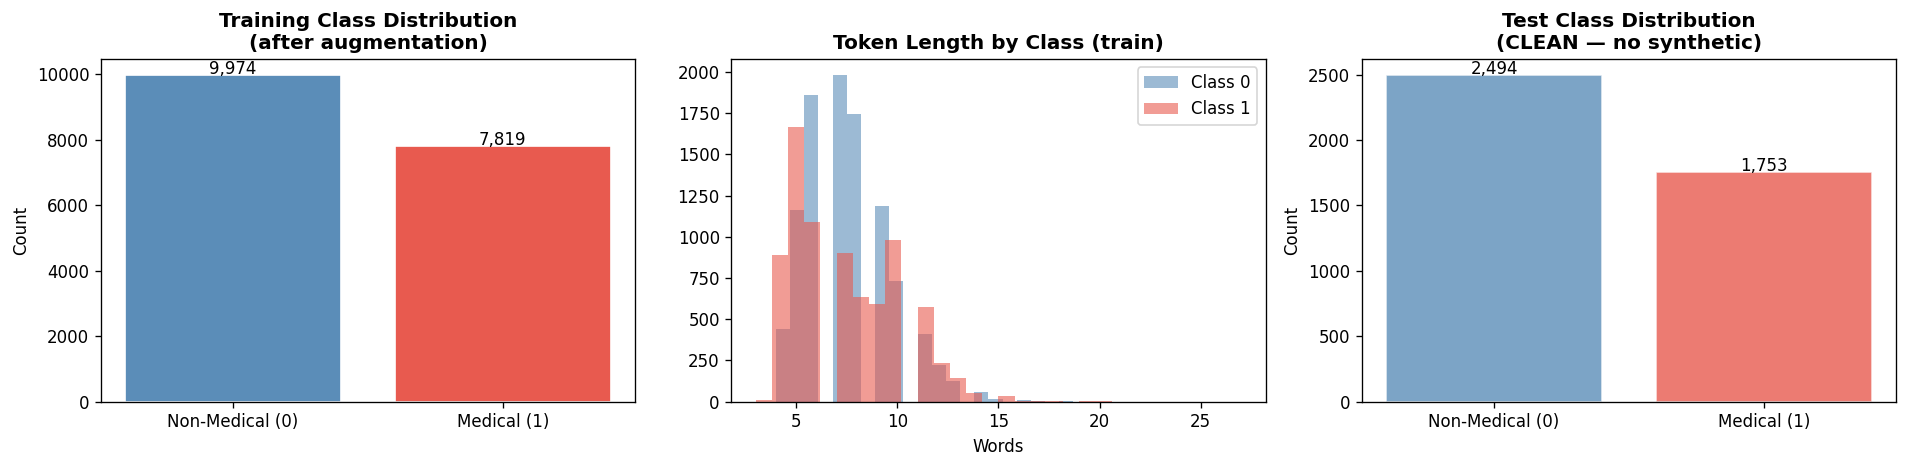

2026-04-06 01:46:19,407 | INFO     | EDA saved → eda_overview.png


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 47: character maps to <undefined>
Call stack:
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_a

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Class distribution in augmented training set
train_counts = y_train.value_counts()
axes[0].bar(["Non-Medical (0)", "Medical (1)"],
            [train_counts.get(0, 0), train_counts.get(1, 0)],
            color=["#5B8DB8", "#E85A4F"], edgecolor="white")
axes[0].set_title("Training Class Distribution\n(after augmentation)", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate([train_counts.get(0,0), train_counts.get(1,0)]):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=10)

# 2. Text length by class (training)
train_lengths = X_train.str.split().apply(len)
for label, color in [(0, "#5B8DB8"), (1, "#E85A4F")]:
    mask = y_train == label
    axes[1].hist(train_lengths[mask], bins=30, alpha=0.6, color=color,
                 label=f"Class {label}")
axes[1].set_title("Token Length by Class (train)", fontweight="bold")
axes[1].set_xlabel("Words")
axes[1].legend()

# 3. Test set distribution (should match raw dataset)
test_counts = y_test.value_counts()
axes[2].bar(["Non-Medical (0)", "Medical (1)"],
            [test_counts.get(0, 0), test_counts.get(1, 0)],
            color=["#5B8DB8", "#E85A4F"], edgecolor="white", alpha=0.8)
axes[2].set_title("Test Class Distribution\n(CLEAN — no synthetic)", fontweight="bold")
axes[2].set_ylabel("Count")
for i, v in enumerate([test_counts.get(0,0), test_counts.get(1,0)]):
    axes[2].text(i, v + 10, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
logger.info("EDA saved → eda_overview.png")

## Baselines ──

In [10]:
baselines = {
    "Majority Class":    DummyClassifier(strategy="most_frequent", random_state=SEED),
    "Stratified Random": DummyClassifier(strategy="stratified",    random_state=SEED),
    "Uniform Random":    DummyClassifier(strategy="uniform",       random_state=SEED),
}

print("=" * 55)
print("BASELINE RESULTS  (any real model must beat these)")
print("=" * 55)
for name, clf in baselines.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="macro", zero_division=0)
    print(f"  {name:<22}  Acc={acc:.4f}  MacroF1={f1:.4f}")
    logger.info(f"Baseline [{name}]: acc={acc:.4f} f1={f1:.4f}")
print("=" * 55)

BASELINE RESULTS  (any real model must beat these)
  Majority Class          Acc=0.5872  MacroF1=0.3700
2026-04-06 01:46:23,824 | INFO     | Baseline [Majority Class]: acc=0.5872 f1=0.3700
  Stratified Random       Acc=0.5150  MacroF1=0.5046
2026-04-06 01:46:23,838 | INFO     | Baseline [Stratified Random]: acc=0.5150 f1=0.5046
  Uniform Random          Acc=0.5182  MacroF1=0.5149
2026-04-06 01:46:23,851 | INFO     | Baseline [Uniform Random]: acc=0.5182 f1=0.5149


## Model Training & Comparison ──

In [11]:
# Shared TF-IDF config for LR and SVC (sublinear_tf helps log-linear models)
TFIDF_LR = dict(ngram_range=(1, 2), max_features=20_000,
                min_df=2, max_df=0.9, sublinear_tf=True)

# Separate TF-IDF config for ComplementNB (no sublinear_tf needed)
TFIDF_NB = dict(ngram_range=(1, 2), max_features=20_000,
                min_df=2, max_df=0.9, sublinear_tf=False)

CANDIDATE_MODELS = {
    "LR (balanced)": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_LR)),
        ("clf",  LogisticRegression(
            max_iter=1000, class_weight="balanced",
            random_state=SEED, C=1.0,
        )),
    ]),
    "LR (med-boost)": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_LR)),
        ("clf",  LogisticRegression(
            max_iter=1000, class_weight={0: 1, 1: 2},
            random_state=SEED, C=1.0,
        )),
    ]),
    # FIX: ComplementNB replaces MultinomialNB
    # - handles TF-IDF correctly
    # - handles class imbalance via complement training
    "ComplementNB": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_NB)),
        ("clf",  ComplementNB(alpha=0.1, norm=True)),
    ]),
    "LinearSVC (calibrated)": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_LR)),
        ("clf",  CalibratedClassifierCV(
            LinearSVC(max_iter=2000, class_weight="balanced", random_state=SEED),
            cv=3,
        )),
    ]),
}

results_rows = []
trained_pipelines = {}

print("Training candidate models ...\n")
for name, pipe in CANDIDATE_MODELS.items():
    t0 = time.time()
    try:
        pipe.fit(X_train, y_train)
        y_pred_m  = pipe.predict(X_test)
        y_proba_m = pipe.predict_proba(X_test)[:, 1]

        row = {
            "Model":    name,
            "Accuracy": round(accuracy_score(y_test, y_pred_m), 4),
            "MacroF1":  round(f1_score(y_test, y_pred_m, average="macro"), 4),
            "MedF1":    round(f1_score(y_test, y_pred_m, pos_label=1), 4),
            "ROC-AUC":  round(roc_auc_score(y_test, y_proba_m), 4),
            "PR-AUC":   round(average_precision_score(y_test, y_proba_m, pos_label=1), 4),
            "Kappa":    round(cohen_kappa_score(y_test, y_pred_m), 4),
            "MCC":      round(matthews_corrcoef(y_test, y_pred_m), 4),
            "Brier":    round(brier_score_loss(y_test, y_proba_m, pos_label=1), 4),  # FIX: explicit pos_label
            "Time(s)":  round(time.time() - t0, 2),
        }
        results_rows.append(row)
        trained_pipelines[name] = pipe
        logger.info(f"[{name}] acc={row['Accuracy']} auc={row['ROC-AUC']} mcc={row['MCC']}")
        print(f"  ✓ {name:<28}  Acc={row['Accuracy']}  AUC={row['ROC-AUC']}  MCC={row['MCC']}")

    except Exception as e:
        logger.error(f"[{name}] FAILED: {e}")
        print(f"  ✗ {name}: FAILED — {e}")

results_df = pd.DataFrame(results_rows).set_index("Model")
print("\n" + "=" * 80)
print("MODEL COMPARISON TABLE")
print("=" * 80)
print(results_df.to_string())
print(f"\n→ Best ROC-AUC : {results_df['ROC-AUC'].idxmax()}")
print(f"→ Best MCC     : {results_df['MCC'].idxmax()}")

Training candidate models ...

2026-04-06 01:46:30,806 | INFO     | [LR (balanced)] acc=0.9908 auc=0.9996 mcc=0.9811
  ✓ LR (balanced)                 Acc=0.9908  AUC=0.9996  MCC=0.9811
2026-04-06 01:46:31,833 | INFO     | [LR (med-boost)] acc=0.9908 auc=0.9997 mcc=0.9811
  ✓ LR (med-boost)                Acc=0.9908  AUC=0.9997  MCC=0.9811
2026-04-06 01:46:32,688 | INFO     | [ComplementNB] acc=0.9887 auc=0.9994 mcc=0.9769
  ✓ ComplementNB                  Acc=0.9887  AUC=0.9994  MCC=0.9769
2026-04-06 01:46:33,734 | INFO     | [LinearSVC (calibrated)] acc=0.9967 auc=0.9998 mcc=0.9932
  ✓ LinearSVC (calibrated)        Acc=0.9967  AUC=0.9998  MCC=0.9932

MODEL COMPARISON TABLE
                        Accuracy  MacroF1   MedF1  ROC-AUC  PR-AUC   Kappa     MCC   Brier  Time(s)
Model                                                                                              
LR (balanced)             0.9908   0.9905  0.9888   0.9996  0.9995  0.9810  0.9811  0.0100     0.94
LR (med-boost)  

In [12]:
# ── 5-Fold Stratified CV ────────────────────────────────────────────────
print("=" * 55)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, pipe in trained_pipelines.items():
    try:
        scores = cross_val_score(
            pipe, X_train, y_train,
            cv=cv, scoring="roc_auc", n_jobs=-1
        )
        print(f"  {name:<28}  {scores.mean():.4f} ± {scores.std():.4f}")
        logger.info(f"CV [{name}]: {scores.mean():.4f} ± {scores.std():.4f}")
    except Exception as e:
        logger.error(f"CV [{name}] failed: {e}")
        print(f"  {name:<28}  ERROR: {e}")

5-Fold Stratified CV (ROC-AUC) — training data only:
  LR (balanced)                 0.9994 ± 0.0002
2026-04-06 01:46:49,343 | INFO     | CV [LR (balanced)]: 0.9994 ± 0.0002
  LR (med-boost)                0.9995 ± 0.0002
2026-04-06 01:47:03,611 | INFO     | CV [LR (med-boost)]: 0.9995 ± 0.0002
  ComplementNB                  0.9994 ± 0.0003
2026-04-06 01:47:18,047 | INFO     | CV [ComplementNB]: 0.9994 ± 0.0003
  LinearSVC (calibrated)        0.9998 ± 0.0002
2026-04-06 01:47:26,494 | INFO     | CV [LinearSVC (calibrated)]: 0.9998 ± 0.0002


In [13]:
BEST_MODEL_NAME = results_df["MCC"].idxmax()
pipeline = trained_pipelines[BEST_MODEL_NAME]

print(f"✅ Best model: '{BEST_MODEL_NAME}'")
print(f"   MCC     = {results_df.loc[BEST_MODEL_NAME, 'MCC']:.4f}")
print(f"   ROC-AUC = {results_df.loc[BEST_MODEL_NAME, 'ROC-AUC']:.4f}")
logger.info(f"Best model: {BEST_MODEL_NAME}")

✅ Best model: 'LinearSVC (calibrated)'
   MCC     = 0.9932
   ROC-AUC = 0.9998
2026-04-06 01:47:40,425 | INFO     | Best model: LinearSVC (calibrated)


## ── SECTION 7: Full Evaluation ──

In [14]:
X_test_clean = X_test  # already clean from pipeline
y_pred  = pipeline.predict(X_test_clean)
y_proba = pipeline.predict_proba(X_test_clean)[:, 1]

print("=" * 60)
print(f"EVALUATION: {BEST_MODEL_NAME}")
print("=" * 60)
print(f"Accuracy      : {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1      : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Medical F1    : {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_proba):.4f}")
print(f"Cohen's Kappa : {cohen_kappa_score(y_test, y_pred):.4f}")
print(f"MCC           : {matthews_corrcoef(y_test, y_pred):.4f}")
print(f"Brier Score   : {brier_score_loss(y_test, y_proba, pos_label=1):.4f}  (↓ better)")
print(f"Log-Loss      : {log_loss(y_test, y_proba):.4f}                       (↓ better)")
print()
print(classification_report(y_test, y_pred, target_names=["Non-Medical", "Medical"]))

EVALUATION: LinearSVC (calibrated)
Accuracy      : 0.9967
Macro F1      : 0.9966
Medical F1    : 0.9960
ROC-AUC       : 0.9998
PR-AUC        : 0.9998
Cohen's Kappa : 0.9932
MCC           : 0.9932
Brier Score   : 0.0027  (↓ better)
Log-Loss      : 0.0117                       (↓ better)

              precision    recall  f1-score   support

 Non-Medical       1.00      1.00      1.00      2494
     Medical       1.00      1.00      1.00      1753

    accuracy                           1.00      4247
   macro avg       1.00      1.00      1.00      4247
weighted avg       1.00      1.00      1.00      4247



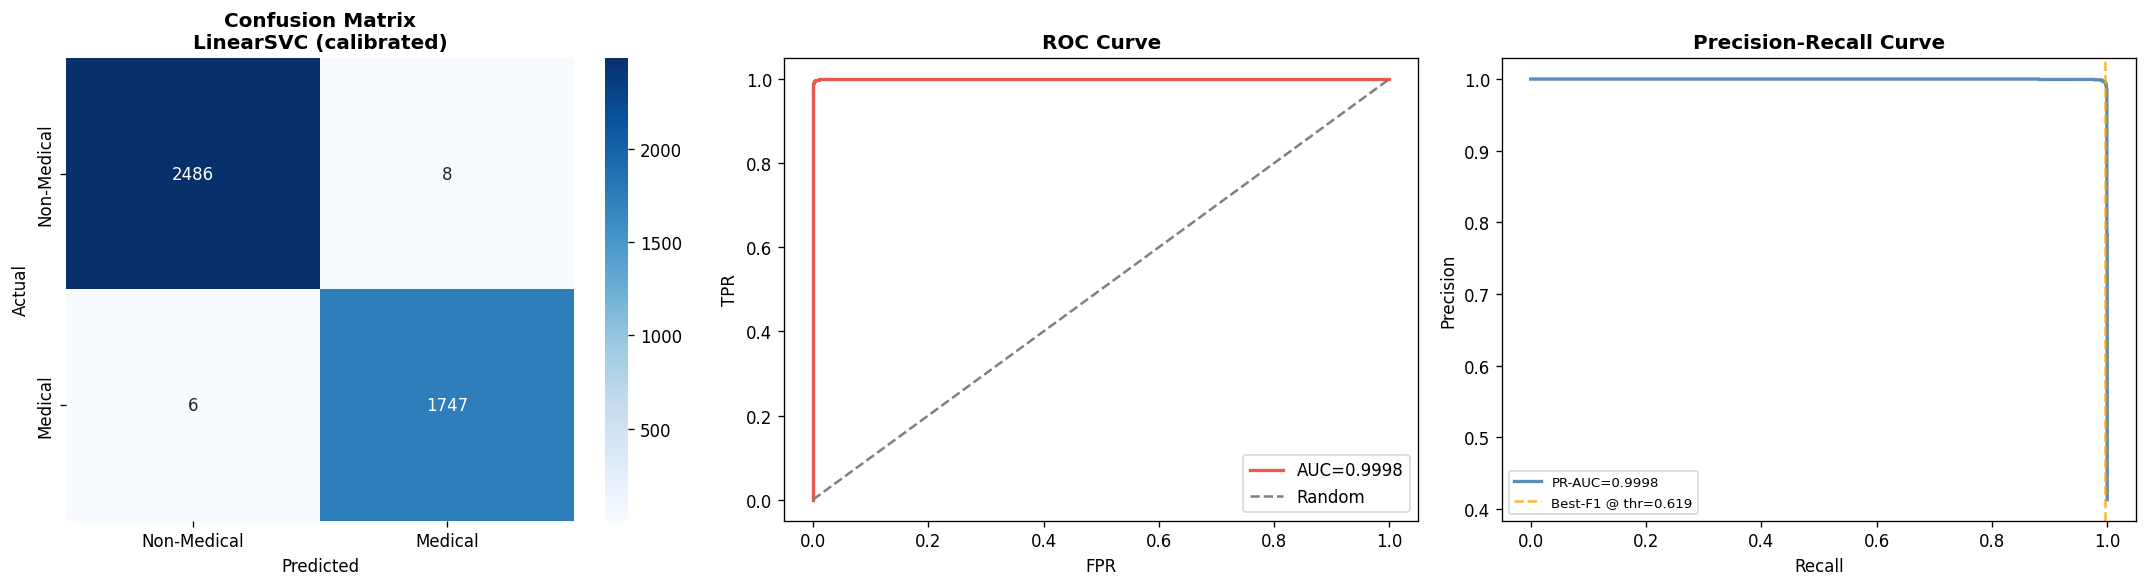


✅ Optimal threshold (max F1): 0.6187
   Precision @ optimal: 0.9966
   Recall    @ optimal: 0.9960
2026-04-06 01:47:50,252 | INFO     | Optimal threshold: 0.6187


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Non-Medical", "Medical"],
            yticklabels=["Non-Medical", "Medical"])
axes[0].set_title(f"Confusion Matrix\n{BEST_MODEL_NAME}", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, color="#E85A4F", label=f"AUC={auc_val:.4f}")
axes[1].plot([0,1],[0,1], "--", color="gray", label="Random")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

# 3. PR Curve + optimal threshold
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
f1_at_thresh  = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_idx      = int(f1_at_thresh.argmax())
OPTIMAL_THRESHOLD = float(thresholds[best_idx])

axes[2].plot(rec, prec, lw=2, color="#5B8DB8",
             label=f"PR-AUC={average_precision_score(y_test, y_proba):.4f}")
axes[2].axvline(rec[best_idx], linestyle="--", color="orange", alpha=0.8,
                label=f"Best-F1 @ thr={OPTIMAL_THRESHOLD:.3f}")
axes[2].set_title("Precision-Recall Curve", fontweight="bold")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n✅ Optimal threshold (max F1): {OPTIMAL_THRESHOLD:.4f}")
print(f"   Precision @ optimal: {prec[best_idx]:.4f}")
print(f"   Recall    @ optimal: {rec[best_idx]:.4f}")
logger.info(f"Optimal threshold: {OPTIMAL_THRESHOLD:.4f}")

## Feature Importance ──

In [16]:
try:
    tfidf_step = pipeline.named_steps["tfidf"]
    clf_step   = pipeline.named_steps["clf"]
    feature_names = np.array(tfidf_step.get_feature_names_out())

    if not hasattr(clf_step, "coef_"):
        print(f"{BEST_MODEL_NAME} has no coef_ — skipping feature importance.")
        raise StopIteration

    coefs = clf_step.coef_[0]   # shape: (n_features,)
    TOP_N = 20

    # FIX: sort index once, use for both words AND values
    # Medical = highest positive coefficients (ascending argsort, take last N, flip)
    med_idx     = np.argsort(coefs)[-TOP_N:][::-1]   # highest → lowest
    nonmed_idx  = np.argsort(coefs)[:TOP_N]           # lowest → highest (most negative)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Medical panel — highest coefficients at the top
    med_words = feature_names[med_idx]
    med_vals  = coefs[med_idx]
    axes[0].barh(range(TOP_N), med_vals, color="#E85A4F", edgecolor="white")
    axes[0].set_yticks(range(TOP_N))
    axes[0].set_yticklabels(med_words, fontsize=9)  
    axes[0].invert_yaxis()                             # top = highest coefficient
    axes[0].set_title("Top 20 → MEDICAL", fontweight="bold")
    axes[0].set_xlabel("LR Coefficient")

    # Non-medical panel — most negative coefficients at the top
    nonmed_words = feature_names[nonmed_idx]
    nonmed_vals  = coefs[nonmed_idx]
    axes[1].barh(range(TOP_N), nonmed_vals, color="#5B8DB8", edgecolor="white")
    axes[1].set_yticks(range(TOP_N))
    axes[1].set_yticklabels(nonmed_words, fontsize=9)  # FIX: matches nonmed_vals directly
    axes[1].set_title("Top 20 → NON-MEDICAL", fontweight="bold")
    axes[1].set_xlabel("LR Coefficient")

    plt.suptitle("Feature Importance (TF-IDF + LR coefficients)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
    plt.show()

    print("Top 10 MEDICAL     :", list(med_words[:10]))
    print("Top 10 NON-MEDICAL :", list(nonmed_words[:10]))
    logger.info("Feature importance saved")

except StopIteration:
    pass
except Exception as e:
    logger.error(f"Feature importance failed: {e}")
    print(f"Skipped: {e}")

LinearSVC (calibrated) has no coef_ — skipping feature importance.


## ── SECTION 9: Local Interpretability ──



In [17]:
def explain_prediction(text: str, top_n: int = 10) -> None:
    """Print word-level contributions to the Medical class score."""
    try:
        tfidf_step = pipeline.named_steps["tfidf"]
        clf_step   = pipeline.named_steps["clf"]

        if not hasattr(clf_step, "coef_"):
            print(f"explain_prediction: '{BEST_MODEL_NAME}' has no coef_, skipping.")
            return

        feature_names = np.array(tfidf_step.get_feature_names_out())
        coefs         = clf_step.coef_[0]

        cleaned       = clean_text(text)  # FIX: apply cleaning
        vec           = tfidf_step.transform([cleaned])
        contributions = np.array(vec.todense())[0] * coefs

        nonzero = np.where(contributions != 0)[0]
        if len(nonzero) == 0:
            print(f"No features matched for: '{text}'")
            return

        top_idx = nonzero[np.argsort(np.abs(contributions[nonzero]))[-top_n:][::-1]]

        proba       = pipeline.predict_proba([cleaned])[0]
        med_prob    = proba[list(pipeline.classes_).index(1)]
        # FIX: use OPTIMAL_THRESHOLD (was hardcoded 0.5)
        pred_label  = "Medical" if med_prob >= OPTIMAL_THRESHOLD else "Non-Medical"

        print(f"\n{'─'*60}")
        print(f"Input      : {text}")
        print(f"Prediction : {pred_label}  (P(medical)={med_prob:.3f},  threshold={OPTIMAL_THRESHOLD:.3f})")
        print(f"{'─'*60}")
        print(f"  {'Token':<28} {'Contribution':>12}  Direction")
        for idx in top_idx:
            direction = "▲ MEDICAL" if contributions[idx] > 0 else "▼ non-med"
            print(f"  {feature_names[idx]:<28} {contributions[idx]:+.4f}  {direction}")

    except Exception as e:
        logger.error(f"explain_prediction error: {e}")
        print(f"Error: {e}")


for ex in [
    "I have chest pain and shortness of breath",
    "Tell me a funny joke",
    "Set an alarm for 7 am",
    "Continuous headache with sensitivity to light",
]:
    explain_prediction(ex)

explain_prediction: 'LinearSVC (calibrated)' has no coef_, skipping.
explain_prediction: 'LinearSVC (calibrated)' has no coef_, skipping.
explain_prediction: 'LinearSVC (calibrated)' has no coef_, skipping.
explain_prediction: 'LinearSVC (calibrated)' has no coef_, skipping.


## Inference ──



In [18]:
def predict_intent(text: str, threshold: float = OPTIMAL_THRESHOLD) -> dict:
    """
    Classify text as Medical or Non-Medical.

    Returns: {label, confidence, medical_prob, threshold_used}
    """
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Input must be a non-empty string.")

    try:
        cleaned      = clean_text(text)   
        proba        = pipeline.predict_proba([cleaned])[0]
        medical_prob = proba[list(pipeline.classes_).index(1)]
        label        = "Medical" if medical_prob >= threshold else "Non-Medical"
        return {
            "label":          label,
            "confidence":     round(medical_prob if label == "Medical" else 1 - medical_prob, 4),
            "medical_prob":   round(medical_prob, 4),
            "threshold_used": round(threshold, 4),
        }
    except Exception as e:
        logger.error(f"predict_intent error for '{text[:50]}': {e}")
        raise


# Quick tests
print(predict_intent("My child has high fever and cough"))
print(predict_intent("Tell me a funny joke"))

print("\nEdge cases:")
for edge in ["asdasd", "123456", "!!!", "pain", "fever", "sick"]:
    r = predict_intent(edge)
    print(f"  {edge!r:<12} → {r['label']:<12}  P(med)={r['medical_prob']}")

{'label': 'Medical', 'confidence': 0.9996, 'medical_prob': 0.9996, 'threshold_used': 0.6187}
{'label': 'Non-Medical', 'confidence': 0.9502, 'medical_prob': 0.0498, 'threshold_used': 0.6187}

Edge cases:
  'asdasd'     → Non-Medical   P(med)=0.1285
  '123456'     → Non-Medical   P(med)=0.1285
  '!!!'        → Non-Medical   P(med)=0.1285
  'pain'       → Medical       P(med)=0.9984
  'fever'      → Medical       P(med)=0.984
  'sick'       → Non-Medical   P(med)=0.0995


In [19]:
TEST_SUITE = {
    "medical": [
        ("I have chest pain and shortness of breath",             1),
        ("My mother is experiencing severe headache",             1),
        ("High fever and persistent cough since yesterday",       1),
        ("Child has vomiting and diarrhea",                       1),
        ("Sudden dizziness and blurred vision",                   1),
        ("Pain in lower abdomen with nausea",                     1),
        ("Severe joint pain and swelling",                        1),
        ("Difficulty breathing and chest tightness",              1),
    ],
    "non_medical": [
        ("Tell me a funny joke",            0),
        ("What is the weather today?",      0),
        ("Book a taxi for me",              0),
        ("Who won the football match?",     0),
        ("Play some music",                 0),
        ("How to cook fried rice?",         0),
        ("Explain machine learning",        0),
        ("Find hotels near Colombo",        0),
    ],
    "edge_cases": [
        ("Set an alarm for 7 am",           0),   # known FP in original
        ("Can you book a doctor?",          1),
        ("I feel tired but play music",     0),
        ("Fever and book me a taxi",        1),
        ("Red itchy rash spreading on skin",1),
        ("Is chest pain serious?",          1),
    ],
}

print(f"{'Input':<55} {'GT':>3} {'Pred':>12} {'P(med)':>7} {'OK':>4}")
print("-" * 87)

total, correct = 0, 0
for category, samples in TEST_SUITE.items():
    print(f"\n[{category.upper()}]")
    for text, gt in samples:
        res      = predict_intent(text)
        pred_int = 1 if res["label"] == "Medical" else 0
        ok       = "✓" if pred_int == gt else "✗"
        if pred_int == gt:
            correct += 1
        total += 1
        print(f"  {text[:52]:<53} {gt:>3} {res['label']:>12} "
              f"{res['medical_prob']:>7.3f} {ok:>4}")

print("-" * 87)
print(f"Suite accuracy: {correct}/{total} = {correct/total:.1%}")
logger.info(f"Test suite: {correct}/{total} correct")

Input                                                    GT         Pred  P(med)   OK
---------------------------------------------------------------------------------------

[MEDICAL]
  I have chest pain and shortness of breath               1      Medical   1.000    ✓
  My mother is experiencing severe headache               1      Medical   1.000    ✓
  High fever and persistent cough since yesterday         1      Medical   1.000    ✓
  Child has vomiting and diarrhea                         1      Medical   0.997    ✓
  Sudden dizziness and blurred vision                     1      Medical   0.994    ✓
  Pain in lower abdomen with nausea                       1      Medical   0.994    ✓
  Severe joint pain and swelling                          1      Medical   0.999    ✓
  Difficulty breathing and chest tightness                1      Medical   0.926    ✓

[NON_MEDICAL]
  Tell me a funny joke                                    0  Non-Medical   0.050    ✓
  What is the weather toda

## Error Analysis ──

Total errors: 14 / 4247  (0.33%)

FALSE POSITIVES (Non-Medical → Medical): 8
  P=0.999  | how do i take notes effectively
  P=0.972  | how do i organize my closet
  P=0.792  | how do you administer oxytetracycline
  P=0.739  | which drug does richard alpert occasionally use
  P=0.738  | what is a risk of liver tumor

FALSE NEGATIVES (Medical → Non-Medical): 6
  P=0.002  | what is isupergonorrhea and why is it concerning
  P=0.137  | what disease is caused by a tumor
  P=0.221  | what is a symptom of overtraining
  P=0.325  | what is the window period in hiv testing
  P=0.386  | what is an example of a topical drug


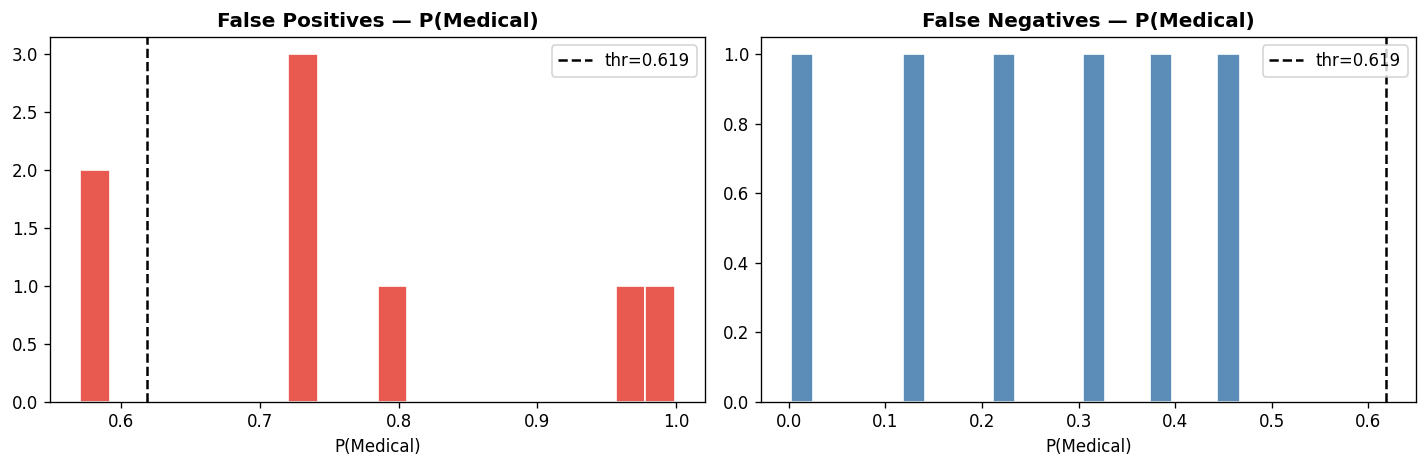

2026-04-06 01:48:15,340 | INFO     | Errors: 8 FP, 6 FN


In [20]:
test_df = pd.DataFrame({"text": X_test.values, "true": y_test.values})
test_df["pred"]  = y_pred
test_df["proba"] = y_proba
test_df["error"] = test_df["true"] != test_df["pred"]

errors = test_df[test_df["error"]].copy()
print(f"Total errors: {len(errors)} / {len(test_df)}  ({len(errors)/len(test_df):.2%})\n")

fp = errors[errors["pred"] == 1].sort_values("proba", ascending=False)
fn = errors[errors["pred"] == 0].sort_values("proba")

print(f"FALSE POSITIVES (Non-Medical → Medical): {len(fp)}")
for _, row in fp.head(5).iterrows():
    print(f"  P={row['proba']:.3f}  | {row['text'][:80]}")

print(f"\nFALSE NEGATIVES (Medical → Non-Medical): {len(fn)}")
for _, row in fn.head(5).iterrows():
    print(f"  P={row['proba']:.3f}  | {row['text'][:80]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title, color in [
    (axes[0], fp, "False Positives — P(Medical)", "#E85A4F"),
    (axes[1], fn, "False Negatives — P(Medical)", "#5B8DB8"),
]:
    if len(data) > 0:
        ax.hist(data["proba"], bins=20, color=color, edgecolor="white")
    ax.axvline(OPTIMAL_THRESHOLD, color="black", linestyle="--",
               label=f"thr={OPTIMAL_THRESHOLD:.3f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("P(Medical)")
    ax.legend()

plt.tight_layout()
plt.savefig("error_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
logger.info(f"Errors: {len(fp)} FP, {len(fn)} FN")

## Save Model ──

In [21]:
import datetime, json, sys

MODEL_PATH    = "intent_classifier_medical_safe.pkl"
METADATA_PATH = "intent_classifier_metadata.json"

try:
    joblib.dump(pipeline, MODEL_PATH)

    metadata = {
        "model_name":        BEST_MODEL_NAME,
        "saved_at":          datetime.datetime.now().isoformat(),
        "seed":              SEED,
        "python_version":    sys.version.split()[0],
        "optimal_threshold": round(OPTIMAL_THRESHOLD, 4),
        "bug_fixes_applied": [
            "test-set-contamination-fixed",
            "complementnb-replaces-multinomialnb",
            "predict-cleans-text",
            "explain-uses-optimal-threshold",
            "feature-importance-alignment-fixed",
            "cv-on-traindata-only",
            "augmentation-after-split",
        ],
        "test_metrics": {
            "accuracy": float(results_df.loc[BEST_MODEL_NAME, "Accuracy"]),
            "macro_f1": float(results_df.loc[BEST_MODEL_NAME, "MacroF1"]),
            "roc_auc":  float(results_df.loc[BEST_MODEL_NAME, "ROC-AUC"]),
            "mcc":      float(results_df.loc[BEST_MODEL_NAME, "MCC"]),
        },
        "train_size": int(len(X_train)),
        "test_size":  int(len(X_test)),
    }

    with open(METADATA_PATH, "w") as f:
        json.dump(metadata, f, indent=2)

    logger.info(f"Model saved → {MODEL_PATH}")
    print(f"✅ Model    → {MODEL_PATH}")
    print(f"✅ Metadata → {METADATA_PATH}")
    print(json.dumps(metadata, indent=2))

except Exception as e:
    logger.error(f"Save failed: {e}")
    raise

2026-04-06 01:48:20,792 | INFO     | Model saved → intent_classifier_medical_safe.pkl
✅ Model    → intent_classifier_medical_safe.pkl
✅ Metadata → intent_classifier_metadata.json
{
  "model_name": "LinearSVC (calibrated)",
  "saved_at": "2026-04-06T01:48:20.790946",
  "seed": 42,
  "python_version": "3.10.19",
  "optimal_threshold": 0.6187,
  "bug_fixes_applied": [
    "test-set-contamination-fixed",
    "complementnb-replaces-multinomialnb",
    "predict-cleans-text",
    "explain-uses-optimal-threshold",
    "feature-importance-alignment-fixed",
    "cv-on-traindata-only",
    "augmentation-after-split"
  ],
  "test_metrics": {
    "accuracy": 0.9967,
    "macro_f1": 0.9966,
    "roc_auc": 0.9998,
    "mcc": 0.9932
  },
  "train_size": 17793,
  "test_size": 4247
}


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 49: character maps to <undefined>
Call stack:
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Chamikara Pasquel\anaconda3\envs\medical_a

In [22]:
# Round-trip verification
loaded  = joblib.load(MODEL_PATH)
test_q  = "My child has high fever and cough"
p_orig  = pipeline.predict_proba([clean_text(test_q)])[0][1]
p_load  = loaded.predict_proba([clean_text(test_q)])[0][1]
assert abs(p_orig - p_load) < 1e-6, f"Mismatch: {p_orig} vs {p_load}"
print(f"✅ Round-trip verified  P(medical)={p_load:.4f}")

with open(METADATA_PATH) as f:
    m = json.load(f)
print(f"   Threshold from metadata: {m['optimal_threshold']}")

✅ Round-trip verified  P(medical)=0.9996
   Threshold from metadata: 0.6187
